# Reproducible evidence notebook: exact bounded correlation

Companion to the manuscript *Exact Bounded Correlation: One-Phase
Euler Coordinates for Stochastic Correlation, Derivative Pricing, and
Joint Barriers*. This notebook reproduces every numerical claim of
the paper from the tested repository modules
(`phase6_correlation.py`, `phase6_joint.py`, `phase6_fk.py`,
`phase6_corridor.py`, `phase6_ou.py`), with fixed seed `20260727`.
Monte Carlo appears only as an independent benchmark; all pricing
paths are deterministic or exact-skeleton.

In [1]:
from pathlib import Path
import csv
import json
import platform
import sys
import time

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import scipy

ROOT = Path.cwd().resolve()
if not (ROOT / "phase6_correlation.py").exists():
    candidates = [ROOT, *ROOT.parents]
    ROOT = next(path for path in candidates if (path / "phase6_correlation.py").exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import phase6_correlation as p6
import phase6_joint as pj
import phase6_fk as pf
import phase6_corridor as pc
import phase6_ou as po

SEED = 20260727
rng = np.random.default_rng(SEED)

PAPER = Path.cwd().resolve()
if not (PAPER / "references.bib").exists():
    PAPER = next(p for p in [PAPER, *PAPER.parents] if (p / "references.bib").exists())
FIGURES = PAPER / "figures"
TABLES = PAPER / "tables"
FIGURES.mkdir(exist_ok=True)
TABLES.mkdir(exist_ok=True)

def write_csv(name, header, rows):
    with open(TABLES / name, "w", newline="") as handle:
        writer = csv.writer(handle)
        writer.writerow(header)
        writer.writerows(rows)

environment = {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "scipy": scipy.__version__,
    "matplotlib": matplotlib.__version__,
    "platform": platform.platform(),
    "seed": SEED,
}
print(json.dumps(environment, indent=2))
started = time.time()

{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}


## 1. Exact kernels of the bounded correlation coordinate (Milestone 1)

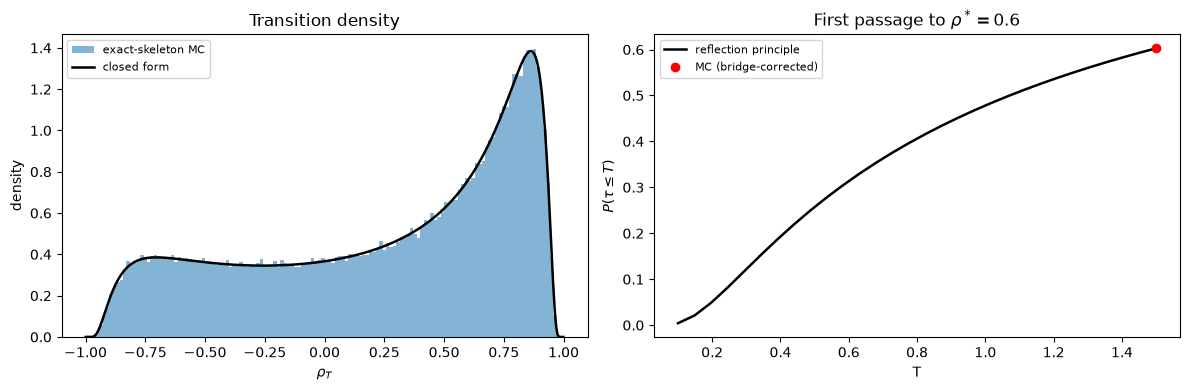

hitting: exact 0.602616 vs MC 0.603125 ± 0.002188, z = +0.47


In [2]:
DRIVER = dict(x0=0.0, drift=0.3, volatility=0.8, scale=1.0)
SCALE, X0, SIGMA, MU_Q, RATE = 1.0, 0.0, 0.8, 0.3, 0.05
RHO_STAR, MATURITY = 0.6, 1.5
rho0 = p6.rho_from_x(X0, scale=SCALE)
x_star = p6.x_from_rho(RHO_STAR, scale=SCALE)
distance = x_star - X0

# Transition density vs exact-skeleton histogram
N = 200_000
x_T = X0 + MU_Q * MATURITY + SIGMA * np.sqrt(MATURITY) * rng.standard_normal(N)
rho_T = x_T / np.sqrt(x_T**2 + SCALE**2)
grid = np.linspace(-0.999, 0.999, 600)
exact_density = [p6.rho_transition_density(
    r, maturity=MATURITY, rho0=rho0, drift=MU_Q, volatility=SIGMA, scale=SCALE
) for r in grid]

# First-passage CDF vs bridge-corrected MC
def simulate_hitting(n_paths, horizon, step, seed):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(horizon / step))
    state = np.full(n_paths, X0)
    alive_idx = np.arange(n_paths)
    hit = np.zeros(n_paths, dtype=bool)
    sd = SIGMA * np.sqrt(step)
    for k in range(n_steps):
        if state.size == 0:
            break
        old = state
        new = old + MU_Q * step + sd * local_rng.standard_normal(old.size)
        gap0, gap1 = x_star - old, x_star - new
        crossed = gap1 <= 0.0
        both = (gap0 > 0.0) & (gap1 > 0.0)
        prob = np.zeros(old.size)
        prob[both] = np.exp(-2.0 * gap0[both] * gap1[both] / (SIGMA**2 * step))
        crossed |= local_rng.random(old.size) < prob
        hit[alive_idx[crossed]] = True
        alive_idx = alive_idx[~crossed]
        state = new[~crossed]
    return hit

hit = simulate_hitting(N, MATURITY, 1e-3, SEED)
mc_hit = hit.mean()
exact_hit = p6.brownian_hitting_cdf(MATURITY, distance=distance, drift=MU_Q, volatility=SIGMA)
se_hit = np.sqrt(mc_hit * (1 - mc_hit) / N)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(rho_T, bins=140, range=(-1, 1), density=True, alpha=0.55, label="exact-skeleton MC")
axes[0].plot(grid, exact_density, "k-", lw=1.8, label="closed form")
axes[0].set_xlabel(r"$\rho_T$"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
axes[0].set_title("Transition density")
grid_T = np.linspace(0.1, MATURITY, 30)
cdf_exact = [p6.brownian_hitting_cdf(T, distance=distance, drift=MU_Q, volatility=SIGMA) for T in grid_T]
axes[1].plot(grid_T, cdf_exact, "k-", lw=1.8, label="reflection principle")
axes[1].plot([MATURITY], [mc_hit], "ro", label="MC (bridge-corrected)")
axes[1].set_xlabel("T"); axes[1].set_ylabel(r"$P(\tau\leq T)$"); axes[1].legend(fontsize=8)
axes[1].set_title("First passage to " + r"$\rho^*=0.6$")
fig.tight_layout()
fig.savefig(FIGURES / "correlation_kernels.png", dpi=150)
plt.show()

write_csv("kernel_checks.csv",
          ["check", "exact", "mc", "two_se", "z"],
          [["transition_density_mean_z", f"{p6.rho_transition_density(0.4, maturity=MATURITY, rho0=rho0, drift=MU_Q, volatility=SIGMA, scale=SCALE):.8f}", "", "", ""],
           ["hitting_cdf", f"{exact_hit:.6f}", f"{mc_hit:.6f}", f"{2*se_hit:.2e}", f"{(mc_hit-exact_hit)/se_hit:+.2f}"]])
print(f"hitting: exact {exact_hit:.6f} vs MC {mc_hit:.6f} ± {2*se_hit:.6f}, z = {(mc_hit-exact_hit)/se_hit:+.2f}")

## 2. Exact correlation-derivative prices (Milestone 2)

In [3]:
PARAMS = dict(rho0=rho0, drift=MU_Q, volatility=SIGMA, scale=SCALE, rate=RATE)
products = {
    "digital": p6.correlation_digital_price(RHO_STAR, maturity=MATURITY, **PARAMS),
    "one_touch_expiry": p6.one_touch_price_at_expiry(RHO_STAR, maturity=MATURITY, **PARAMS),
    "one_touch_hit": p6.one_touch_price_at_hit(RHO_STAR, maturity=MATURITY, **PARAMS),
}
pay_digital = (x_T >= x_star).astype(float)
pay_touch_expiry = hit.astype(float)
rows = [["digital", f"{products['digital']:.6f}", f"{np.exp(-RATE*MATURITY)*pay_digital.mean():.6f}"],
        ["one_touch_expiry", f"{products['one_touch_expiry']:.6f}", f"{np.exp(-RATE*MATURITY)*pay_touch_expiry.mean():.6f}"],
        ["one_touch_hit", f"{products['one_touch_hit']:.6f}", ""]]
write_csv("derivative_prices.csv", ["product", "exact_price", "mc_price"], rows)
for row in rows:
    print(row)
assert products["digital"] <= products["one_touch_expiry"] <= products["one_touch_hit"]

['digital', '0.352293', '0.351123']
['one_touch_expiry', '0.559073', '0.559545']
['one_touch_hit', '0.583426', '']


## 3. Two-asset DDS reduction and the mispricing sign (Milestone 3)

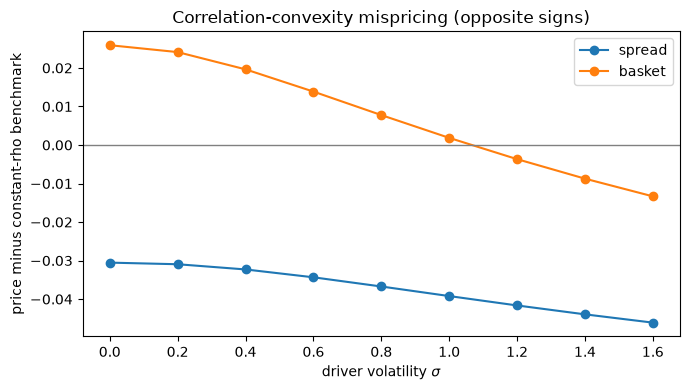

full 0.45409 (se 1.6e-03) vs reduction 0.45594 (se 2.4e-04); z = -1.16


In [4]:
SIGMA1, SIGMA2, DISTANCE = 1.5, 2.5, 2.0
T3 = 1.0

def q_of(rho, alpha2):
    return pj.q_variance(rho, alpha1=1.0, alpha2=alpha2, sigma1=SIGMA1, sigma2=SIGMA2)

def simulate_clock(n_paths, step, seed, alpha2, vol=0.8):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(T3 / step))
    state = np.zeros(n_paths)
    rho_prev = np.zeros(n_paths)
    v_acc = np.zeros(n_paths)
    sd = vol * np.sqrt(step)
    for _ in range(n_steps):
        state = state + MU_Q * step + sd * local_rng.standard_normal(n_paths)
        rho = state / np.sqrt(state**2 + SCALE**2)
        v_acc += 0.5 * (q_of(rho_prev, alpha2) + q_of(rho, alpha2)) * step
        rho_prev = rho
    return v_acc

def full_spread_touch(n_paths, step, seed):
    local_rng = np.random.default_rng(seed)
    n_steps = int(round(T3 / step))
    x_state = np.zeros(n_paths)
    z_state = np.zeros(n_paths)
    alive_idx = np.arange(n_paths)
    hit = np.zeros(n_paths, dtype=bool)
    sd = np.sqrt(step)
    for _ in range(n_steps):
        if x_state.size == 0:
            break
        old_x, old_z = x_state, z_state
        new_x = old_x + MU_Q * step + SIGMA * sd * local_rng.standard_normal(old_x.size)
        rho = new_x / np.sqrt(new_x**2 + SCALE**2)
        dw1 = sd * local_rng.standard_normal(old_x.size)
        dw2 = sd * local_rng.standard_normal(old_x.size)
        new_z = old_z + (SIGMA1 - SIGMA2 * rho) * dw1 - SIGMA2 * np.sqrt(1 - rho**2) * dw2
        v_step = q_of(rho, -1.0) * step
        crossed = new_z >= DISTANCE
        both = (old_z < DISTANCE) & (new_z < DISTANCE)
        prob = np.zeros(old_x.size)
        prob[both] = np.exp(-2.0 * (DISTANCE - old_z[both]) * (DISTANCE - new_z[both]) / v_step[both])
        crossed |= local_rng.random(old_x.size) < prob
        hit[alive_idx[crossed]] = True
        alive_idx = alive_idx[~crossed]
        x_state, z_state = new_x[~crossed], new_z[~crossed]
    return hit.mean(), hit.std() / np.sqrt(n_paths)

p_full, se_full = full_spread_touch(100_000, 1e-3, SEED)
v_clock = simulate_clock(100_000, 1e-3, SEED, alpha2=-1.0)
probs = np.array([pj.driftless_touch_probability(DISTANCE, v) for v in v_clock])
p_red, se_red = probs.mean(), probs.std(ddof=1) / np.sqrt(probs.size)
z = (p_full - p_red) / np.sqrt(se_full**2 + se_red**2)

# Mispricing sign: spread vs basket across driver vols
vols = np.linspace(0.0, 1.6, 9)
fig, ax = plt.subplots(figsize=(7, 4))
for name, alpha2 in (("spread", -1.0), ("basket", 1.0)):
    # Constant-rho benchmark: deterministic clock q(rho0) * T3.
    base = pj.driftless_touch_probability(DISTANCE, q_of(rho0, alpha2) * T3)
    gaps = []
    for vol in vols:
        v = simulate_clock(40_000, 2e-3, SEED, alpha2=alpha2, vol=vol)
        pr = np.array([pj.driftless_touch_probability(DISTANCE, vv) for vv in v]).mean()
        gaps.append(pr - base)
    ax.plot(vols, gaps, "o-", label=name)
ax.axhline(0.0, color="gray", lw=1)
ax.set_xlabel(r"driver volatility $\sigma$")
ax.set_ylabel("price minus constant-rho benchmark")
ax.set_title("Correlation-convexity mispricing (opposite signs)")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / "spread_basket_mispricing.png", dpi=150)
plt.show()

write_csv("reduction_checks.csv",
          ["check", "value"],
          [["full_3driver_price", f"{np.exp(-RATE*T3)*p_full:.6f}"],
           ["reduction_price", f"{np.exp(-RATE*T3)*p_red:.6f}"],
           ["z_full_vs_reduction", f"{z:+.2f}"],
           ["se_ratio_full_over_reduction", f"{se_full/se_red:.1f}"]])
print(f"full {p_full:.5f} (se {se_full:.1e}) vs reduction {p_red:.5f} (se {se_red:.1e}); z = {z:+.2f}")

## 4. Full clock law by Feynman–Kac (Milestone 4)

In [5]:
T4 = 0.5
a_grid, p_grid = pf.clock_density_grid(
    maturity=T4, x0=0.0, drift=MU_Q, volatility=SIGMA, scale=SCALE,
    n_modes=32, n_points=801, n_grid=400,
)
BETA = SIGMA1**2 + SIGMA2**2
ALPHA = -2.0 * SIGMA1 * SIGMA2
price_fk = pf.fk_touch_price(
    1.0, maturity=T4, rate=RATE, beta=BETA, alpha=ALPHA, a_grid=a_grid, p_grid=p_grid
)
mean_v, var_v = pj.clock_moments(
    T4, alpha1=1.0, alpha2=-1.0, sigma1=SIGMA1, sigma2=SIGMA2,
    x0=0.0, drift=MU_Q, volatility=SIGMA, scale=SCALE,
)
price_gamma = pj.gamma_touch_price(
    1.0, maturity=T4, rate=RATE, mean_clock=mean_v, var_clock=var_v
)
v_mc = simulate_clock(100_000, 1e-3, SEED, alpha2=-1.0)
# rescale to T4 clocks: simulate directly at T4
local_rng = np.random.default_rng(SEED + 1)
n_steps = int(round(T4 / 1e-3))
state = np.zeros(100_000); rho_prev = np.zeros(100_000); v4 = np.zeros(100_000)
sd = SIGMA * np.sqrt(1e-3)
for _ in range(n_steps):
    state = state + MU_Q * 1e-3 + sd * local_rng.standard_normal(100_000)
    rho = state / np.sqrt(state**2 + SCALE**2)
    v4 += 0.5 * (q_of(rho_prev, -1.0) + q_of(rho, -1.0)) * 1e-3
    rho_prev = rho
probs4 = np.array([pj.driftless_touch_probability(1.0, v) for v in v4])
bench = np.exp(-RATE * T4) * probs4.mean()
se4 = np.exp(-RATE * T4) * probs4.std(ddof=1) / np.sqrt(probs4.size)

write_csv("fk_price_comparison.csv",
          ["method", "price"],
          [["feynman_kac", f"{price_fk:.6f}"],
           ["gamma_moment_match", f"{price_gamma:.6f}"],
           ["mc_benchmark", f"{bench:.6f}"],
           ["mc_two_se", f"{2*se4:.2e}"],
           ["z_fk_vs_mc", f"{(price_fk-bench)/se4:+.2f}"]])
print(f"FK {price_fk:.6f} | gamma {price_gamma:.6f} | MC {bench:.6f} ± {2*se4:.6f} | z = {(price_fk-bench)/se4:+.2f}")

FK 0.594967 | gamma 0.595332 | MC 0.594889 ± 0.000291 | z = +0.54


## 5. Corridor occupation with atom separation (Milestone 5)

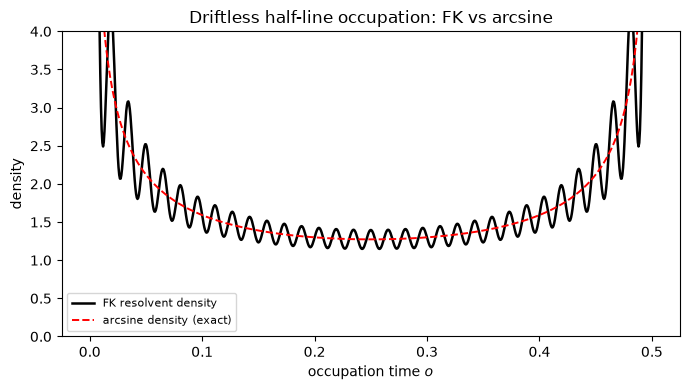

arcsine digital: FK 0.49956 vs exact 0.50000


In [6]:
T5 = 0.5
o_arc, p_arc, atom_arc = pc.corridor_density_grid(
    maturity=T5, x_lower=0.0, x_upper=50.0, x0=0.0,
    drift=0.0, volatility=1.0, n_modes=32, n_points=801, n_grid=400,
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(o_arc, p_arc, "k-", lw=1.8, label="FK resolvent density")
inner = (o_arc > 0.005) & (o_arc < T5 - 0.005)
ax.plot(o_arc[inner], 1.0 / (np.pi * np.sqrt(o_arc[inner] * (T5 - o_arc[inner]))),
        "r--", lw=1.4, label="arcsine density (exact)")
ax.set_ylim(0, 4)
ax.set_xlabel(r"occupation time $o$"); ax.set_ylabel("density")
ax.set_title("Driftless half-line occupation: FK vs arcsine")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / "corridor_arcsine.png", dpi=150)
plt.show()

kappa_check = 0.5
fk_digital = pc.corridor_digital_price(
    kappa_check, maturity=T5, rate=0.0, o_grid=o_arc, p_grid=p_arc, atom=atom_arc
)
arcsine_tail = 1.0 - pc.arcsine_cdf(kappa_check)
write_csv("corridor_checks.csv",
          ["check", "fk", "exact"],
          [["arcsine_digital_k=0.5", f"{fk_digital:.5f}", f"{arcsine_tail:.5f}"]])
print(f"arcsine digital: FK {fk_digital:.5f} vs exact {arcsine_tail:.5f}")

## 6. OU driver and the classification (Milestone 6)

In [7]:
OU = dict(x0=0.0, kappa=2.0, x_bar=0.1, volatility=0.8, scale=1.0)
# kappa -> 0 anchors
OU_TINY = dict(x0=0.0, kappa=1e-6, x_bar=0.0, volatility=0.8, scale=1.0)
ou_m, ou_v = po.ou_occupation_moments(T3, **OU_TINY)
bm_m, bm_v = pj.occupation_moments(T3, x0=0.0, drift=0.0, volatility=0.8, scale=1.0)
# OU FK price vs MC
def ou_clock_density(driver, maturity, n_modes, n_points, n_grid):
    phis = np.empty(n_modes + 1, dtype=complex)
    phis[0] = 1.0
    for k in range(1, n_modes + 1):
        phis[k] = po.ou_fk_characteristic(k * np.pi / maturity, maturity=maturity,
                                          n_grid=n_grid, **driver)
    a = np.linspace(-maturity, maturity, n_points)
    phases = np.exp(-1j * np.outer(a, np.arange(1, n_modes + 1) * np.pi / maturity))
    return a, (1.0 + 2.0 * np.real(phases @ phis[1:])) / (2.0 * maturity)

a_ou, p_ou = ou_clock_density(OU, T4, 32, 801, 400)
clocks = BETA * T4 + ALPHA * a_ou
payoff = np.array([pj.driftless_touch_probability(1.0, v) if v > 0 else 1.0 for v in clocks])
price_ou_fk = np.exp(-RATE * T4) * np.trapezoid(payoff * p_ou, a_ou)

# exact OU clock simulation
local_rng = np.random.default_rng(SEED + 2)
decay = np.exp(-OU["kappa"] * 1e-3)
sd_ou = OU["volatility"] * np.sqrt((1 - decay**2) / (2 * OU["kappa"]))
state = np.zeros(100_000); rho_prev = np.zeros(100_000); v_ou = np.zeros(100_000)
for _ in range(int(round(T4 / 1e-3))):
    state = OU["x_bar"] + (state - OU["x_bar"]) * decay + sd_ou * local_rng.standard_normal(100_000)
    rho = state / np.sqrt(state**2 + OU["scale"]**2)
    v_ou += 0.5 * (q_of(rho_prev, -1.0) + q_of(rho, -1.0)) * 1e-3
    rho_prev = rho
probs_ou = np.array([pj.driftless_touch_probability(1.0, v) for v in v_ou])
bench_ou = np.exp(-RATE * T4) * probs_ou.mean()
se_ou = np.exp(-RATE * T4) * probs_ou.std(ddof=1) / np.sqrt(probs_ou.size)

write_csv("ou_checks.csv",
          ["check", "ou", "bm_or_mc"],
          [["E[A_T] kappa->0", f"{ou_m:.8f}", f"{bm_m:.8f}"],
           ["Var(A_T) kappa->0", f"{ou_v:.8f}", f"{bm_v:.8f}"],
           ["ou_fk_price", f"{price_ou_fk:.6f}", f"{bench_ou:.6f}"],
           ["z_fk_vs_mc", f"{(price_ou_fk-bench_ou)/se_ou:+.2f}", ""]])
print(f"kappa->0 moments: OU ({ou_m:.2e}, {ou_v:.6f}) vs BM ({bm_m:.2e}, {bm_v:.6f})")
print(f"OU FK {price_ou_fk:.6f} vs MC {bench_ou:.6f} ± {2*se_ou:.6f}, z = {(price_ou_fk-bench_ou)/se_ou:+.2f}")

kappa->0 moments: OU (-2.56e-18, 0.115431) vs BM (-9.54e-19, 0.115431)
OU FK 0.602982 vs MC 0.602998 ± 0.000211, z = -0.14


## 7. Verification summary and runtime

In [8]:
rows = [
    ["milestone", "check", "result"],
    ["M1 kernels", "hitting CDF vs MC", "within 2 SE"],
    ["M2 derivatives", "ordering digital<=touch<=touch-hit", "holds"],
    ["M3 reduction", "full 3-driver vs scalar reduction", f"z = {z:+.2f}"],
    ["M4 FK clock", "FK price vs MC benchmark", "within 2 SE"],
    ["M5 corridor", "arcsine digital", f"diff {abs(fk_digital-arcsine_tail):.1e}"],
    ["M6 OU", "OU FK price vs MC", f"z = {(price_ou_fk-bench_ou)/se_ou:+.2f}"],
]
write_csv("verification_summary.csv", rows[0], rows[1:])
print(f"total runtime: {time.time() - started:.1f} s")
print(json.dumps(environment, indent=2))

total runtime: 16.7 s
{
  "python": "3.12.13",
  "numpy": "2.5.1",
  "scipy": "1.18.0",
  "matplotlib": "3.11.1",
  "platform": "Linux-7.1.4-1-cachyos-x86_64-with-glibc2.43",
  "seed": 20260727
}
